In [36]:
import pandas as pd
from pathlib import Path
import re

def _canon(s: str) -> str:
    """Lowercase and remove non-alphanumerics for flexible header matching."""
    return re.sub(r'[^0-9a-z]+', '', str(s).lower())

def _attempt_map_columns(df, verbose=True):
    """
    Try to map a file *with headers* to ['time','rawpsi','tide_m','temp'].
    Returns (df_renamed, success_bool).
    """
    # Clean column names
    clean_cols = []
    for c in df.columns:
        c0 = str(c).replace("\ufeff", "").strip()
        c0 = re.sub(r'\s*\(\s*', '(', c0)  # "tide (m)" -> "tide(m)"
        c0 = re.sub(r'\s*\)\s*', ')', c0)  # "temperature (degC )" -> "temperature(degC)"
        clean_cols.append(c0)
    df.columns = clean_cols

    if verbose:
        print("Detected columns:", list(df.columns))

    # Known header variants
    targets = {
        "time":   {"time","datetime","timestamp","date","datestamp"},
        "rawpsi": {"pressurepsi","pressure","psi","pressurespsi","pressure(psi)"},
        "tide_m": {"tide","tidem","tide_m","tide(m)"},
        "temp":   {"temp","temperature","temperaturedegc","temperature(c)","temperature(degc)","tempc"},
    }

    rename_map = {}
    canon_to_src = { _canon(c): c for c in df.columns }

    for want, variants in targets.items():
        found = None
        # Exact variant match
        for v in variants:
            if v in canon_to_src:
                found = canon_to_src[v]
                break
        # Heuristics if needed
        if found is None:
            for k, src in canon_to_src.items():
                if want == "rawpsi" and (k.startswith("pressure") or k.endswith("psi") or "psi" in k):
                    found = src; break
                if want == "tide_m" and ("tide" in k):
                    found = src; break
                if want == "temp" and ("temp" in k or "temperature" in k):
                    found = src; break
                if want == "time" and ("time" in k or "date" in k or "stamp" in k):
                    found = src; break
        if found is not None:
            rename_map[found] = want

    if verbose:
        print("Column mapping:", rename_map)

    df2 = df.rename(columns=rename_map)
    required = ["time","rawpsi","tide_m","temp"]
    success = all(c in df2.columns for c in required)
    return df2, success

def convert_F2025_to_MJ03F(
    infile: str,
    outfile: str = 'MJ03F2025NANO.Data',
    *,
    rho_seawater=1025.0,
    g=9.80665,
    m_per_psi=0.67,        # set to None for physics-accurate (~0.6859215 m/psi)
    write_header=False,    # <<< make output headerless to match your reader
    verbose=True,
):
    """
    Convert an F2025_* pressure/tide/temp file to MJ03F-style:
      input columns (order): Time, Pressure(psi), tide(m), temperature(degC)
      output columns:        time, rawpsi, depth, temp

    depth (m) = rawpsi * m_per_psi - tide(m)
    """
    # Pass 1: try reading with header and map columns
    df = pd.read_csv(infile, sep=None, engine="python")
    df_try, ok = _attempt_map_columns(df.copy(), verbose=verbose)

    # If mapping failed, it's likely headerless: re-read with known schema
    if not ok:
        if verbose:
            print("No usable header detected. Re-reading as headerless...")
        df_try = pd.read_csv(
            infile, sep=None, engine="python",
            header=None, names=["time","rawpsi","tide_m","temp"]
        )

    # Parse types
    df_try["time"] = pd.to_datetime(df_try["time"], errors="coerce")
    df_try = df_try.dropna(subset=["time"]).sort_values("time")
    for c in ["rawpsi","tide_m","temp"]:
        df_try[c] = pd.to_numeric(df_try[c], errors="coerce")

    # If m_per_psi is None, compute physics-based conversion (≈0.6859215 m/psi @ 1025 kg/m³)
    if m_per_psi is None:
        PSI_TO_PA = 6894.757
        m_per_psi = PSI_TO_PA / (rho_seawater * g)

    # Detided depth
    df_try["depth"] = df_try["rawpsi"] * m_per_psi - df_try["tide_m"]

    out = df_try[["time","rawpsi","depth","temp"]].copy()

    # --- Ensure your downstream reader (header=None) is happy ---
    # 1) Format time consistently
    out["time"] = out["time"].dt.strftime("%Y-%m-%d %H:%M:%S")
    # 2) Write without header if requested
    Path(outfile).parent.mkdir(parents=True, exist_ok=True)
    out.to_csv(outfile, index=False, header=write_header)  # <<< key change

    if verbose:
        print(f"m_per_psi used: {m_per_psi:.9f} m/psi")
        print(f"Wrote: {outfile} ({len(out)} rows) | header={write_header}")

    return out, outfile

# --- Run it (edit the filenames if needed) ---
if __name__ == "__main__":
    inpath  = "B2025_all.dat"           # your input file
    outpath = "MJ03B2025NANO.Data"      # desired output filename
    out_df, out_file = convert_F2025_to_MJ03F(
        inpath, outfile=outpath,
        m_per_psi=0.67, write_header=False, verbose=True
    )
    print(f"Done: {out_file}")


Detected columns: ['2025-01-01 00:00:00', '2274.667690067', '-0.398059994', '3.143778931']
Column mapping: {}
No usable header detected. Re-reading as headerless...
m_per_psi used: 0.670000000 m/psi
Wrote: MJ03B2025NANO.Data (1485526 rows) | header=False
Done: MJ03B2025NANO.Data


In [14]:
combined_df3=pd.read_pickle('/data/wsd02/maleen_data/Data2503.pkl')
combined_df2=pd.read_pickle('/data/wsd02/maleen_data/Data2502.pkl')
combined_df4=pd.read_pickle('/data/wsd02/maleen_data/Data2504.pkl')

In [37]:
import glob
# Specify the path and pattern to load multiple files
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03F*.Data")  # adjust path as needed

# Read and concatenate all files
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)

# Combine into one DataFrame
cp = pd.concat(df_list, ignore_index=True).sort_values('time')

cp['time'] = pd.to_datetime(cp['time'])
cp['p']= (cp['depth']/0.67)
cp = cp.reset_index()
cp = cp.drop(columns=["index"])

In [38]:
import glob
# Specify the path and pattern to load multiple files
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03E*.Data")  # adjust path as needed

# Read and concatenate all files
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)

# Combine into one DataFrame
ep = pd.concat(df_list, ignore_index=True).sort_values('time')

ep['time'] = pd.to_datetime(ep['time'])
ep['p']= (ep['depth']/0.67)
ep = ep.reset_index()
ep = ep.drop(columns=["index"])

In [39]:
import glob
# Specify the path and pattern to load multiple files
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03B*.Data")  # adjust path as needed

# Read and concatenate all files
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)

# Combine into one DataFrame
wp = pd.concat(df_list, ignore_index=True).sort_values('time')

wp['time'] = pd.to_datetime(wp['time'])
wp['p']= (wp['depth']/0.67)
wp = wp.reset_index()
wp = wp.drop(columns=["index"])

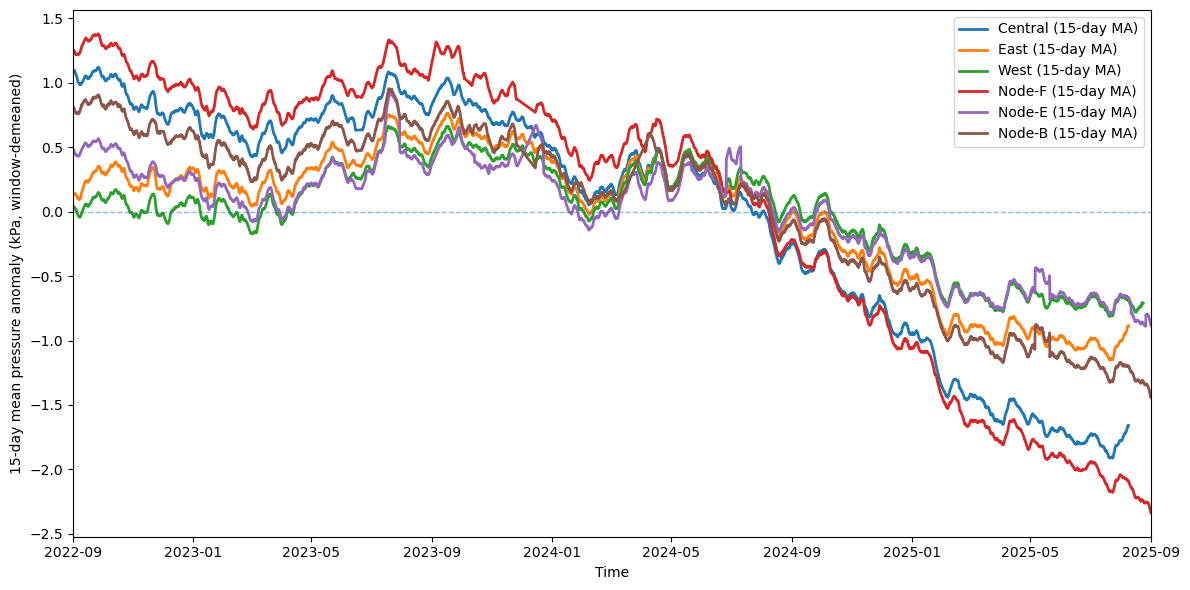

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

PSI_TO_KPA = 6.894757
COL_KPA = 'Corrected Pressure (kPa)'

start = pd.Timestamp('2022-09-01')
end   = pd.Timestamp('2025-09-01')

def to_ma15d(df, tcol, vcol, *, unit='kpa'):
    x = df[[tcol, vcol]].copy()
    x[tcol] = pd.to_datetime(x[tcol], errors='coerce')
    x = x.dropna(subset=[tcol]).sort_values(tcol)
    v = x[vcol].astype(float)
    if unit.lower() == 'psi':
        v = v * PSI_TO_KPA
    s = pd.Series(v.values, index=x[tcol])
    return s.rolling('15D', center=True, min_periods=1).mean()

def rebase_to_window(ma, start, end):
    w = ma.loc[start:end]
    return ma - w.mean()

# 15-day moving averages
ma_c  = to_ma15d(combined_df4, 'DateTime', COL_KPA, unit='kpa')
ma_e  = to_ma15d(combined_df2, 'DateTime', COL_KPA, unit='kpa')
ma_w  = to_ma15d(combined_df3, 'DateTime', COL_KPA, unit='kpa')
ma_cp = to_ma15d(cp,          'time',     'p',      unit='psi')  # cp.p is psi
ma_ep = to_ma15d(ep,          'time',     'p',      unit='psi')  # cp.p is psi
ma_wp = to_ma15d(wp,          'time',     'p',      unit='psi')  # cp.p is psi

# Re-baseline within the plotted window
ma_c  = rebase_to_window(ma_c,  start, end)
ma_e  = rebase_to_window(ma_e,  start, end)
ma_w  = rebase_to_window(ma_w,  start, end)
ma_cp = rebase_to_window(ma_cp, start, end)
ma_ep = rebase_to_window(ma_ep, start, end)
ma_wp = rebase_to_window(ma_wp, start, end)

# Plot only the window
plt.figure(figsize=(12, 6))
for s, name in [(ma_c, 'Central'), (ma_e, 'East'), (ma_w, 'West'), (ma_cp, 'Node-F'),(ma_ep, 'Node-E'),(ma_wp, 'Node-B')]:
    sw = s.loc[start:end]
    if not sw.empty:
        plt.plot(sw.index, sw.values, linewidth=2, label=f'{name} (15-day MA)')

plt.axhline(0, lw=1, ls='--', alpha=0.5)
plt.xlim(start, end)
plt.xlabel('Time')
plt.ylabel('15-day mean pressure anomaly (kPa, window-demeaned)')
plt.legend()
plt.tight_layout()
plt.show()


In [52]:
import numpy as np
import pandas as pd

# ---------- Config ----------
# Define your three fit segments (edit as needed)
SEGMENTS = [
    ("2022-09-01", "2023-09-01"),
    ("2023-09-01", "2025-09-01"),
#    ("2024-07-01", "2025-09-01"),
]
TOL = "2H"      # asof merge tolerance
MIN_PTS = 25    # minimum points per segment to fit

# ---------- Helpers ----------
def asof_merge_pn_pe_pc(ma_c, ma_e, ma_cp, ma_ep, ma_wp, ma_w, tol="2H"):
    """
    Align Pn (ma_c), Pe (ma_e), Pc (ma_cp) onto a common timeline (Pn) for drift fitting.
    Ensures the time column is named 'time' and sorted. Drops duplicates & NaNs.
    """

    def s2df(s, name):
        # ensure datetime index, drop bad stamps
        s = s.dropna()
        s.index = pd.to_datetime(s.index, errors="coerce")
        s = s[~s.index.isna()]
        # make a DataFrame with a guaranteed 'time' column
        df = s.rename(name).rename_axis("time").reset_index()
        # normalize timezone if present
        try:
            df["time"] = df["time"].dt.tz_convert(None)
        except Exception:
            try:
                df["time"] = df["time"].dt.tz_localize(None)
            except Exception:
                pass
        # sort & de-dup
        df = df.sort_values("time")
        df = df[~df["time"].duplicated(keep="first")]
        return df

    pn = s2df(ma_c,  "Pn")   # Pn (ma_c)
    pe = s2df(ma_e,  "Pe")   # Pe (ma_e)
    pc = s2df(ma_cp, "Pc")   # Pc (ma_cp)
    ep = s2df(ma_ep, "ep")
    wp = s2df(ma_wp, "wp")
    pw = s2df(ma_w,  "Pw")
    
    # as-of merges on sorted 'time' column, progressively requiring columns
    m = pd.merge_asof(pn, pe, on="time", direction="nearest", tolerance=pd.Timedelta(tol))
    m = pd.merge_asof(m.dropna(subset=["Pe"]).sort_values("time"),
                      pc, on="time", direction="nearest", tolerance=pd.Timedelta(tol))
    m = pd.merge_asof(m.dropna(subset=["Pc"]).sort_values("time"),
                      ep, on="time", direction="nearest", tolerance=pd.Timedelta(tol))
    m = pd.merge_asof(m.dropna(subset=["ep"]).sort_values("time"),
                      wp, on="time", direction="nearest", tolerance=pd.Timedelta(tol))
    m = pd.merge_asof(m.dropna(subset=["wp"]).sort_values("time"),
                      pw, on="time", direction="nearest", tolerance=pd.Timedelta(tol))    

    # keep rows with all aligned signals present
    m = (m.dropna(subset=["Pe", "Pc", "ep", "wp", "Pw"])
           .sort_values("time")
           .reset_index(drop=True))

    # nice column order
    cols = ["time", "Pn", "Pe", "Pc", "ep", "wp", "Pw"]
    m = m[[c for c in cols if c in m.columns]]

    return m


def fit_segment(df_seg):
    """
    Fit (Pn - Pe) ≈ a + b*(Pc - meanPc) + c*t', where t' is time (days) around the segment center.
    Returns dict with a,b,c and diagnostics.
    """
    # Demean within the segment to stabilize a; keep Pe in the difference
    dPn = df_seg["Pn"] - df_seg["Pn"].mean()
    dPe = df_seg["Pe"] - df_seg["Pe"].mean()
    dPc = df_seg["Pc"] - df_seg["Pc"].mean()

    Y = (dPn - dPe).to_numpy(dtype=float)
    X = dPc.to_numpy(dtype=float)

    t_mid = df_seg["time"].iloc[0] + (df_seg["time"].iloc[-1] - df_seg["time"].iloc[0]) / 2
    t_days = (df_seg["time"] - t_mid).dt.total_seconds().to_numpy() / 86400.0

    # Design: [1, X, t']
    A = np.column_stack([np.ones_like(X), X, t_days])
    a, b, c = np.linalg.lstsq(A, Y, rcond=None)[0]  # Y ≈ a + b*X + c*t'

    Yhat = A @ np.array([a,b,c])
    resid = Y - Yhat
    rmse = float(np.sqrt(np.mean(resid**2)))

    return {
        "a": float(a), "b": float(b), "c": float(c),  # c is drift rate kPa/day (Pn minus Pe)
        "rmse_kPa": rmse,
        "n": int(len(df_seg)),
        "t_mid": t_mid,
    }

def build_piecewise_correction(times, segments, fits):
    """
    Build a continuous, piecewise-linear drift correction for Pn using c (kPa/day) per segment.
    `times` should be the merged["time"] Series. We return a Series indexed by the SAME ROW INDEX
    (not by the datetime values) to avoid boolean-index alignment issues.
    """
    # Ensure Series of datetimes, no tz
    times = pd.to_datetime(times, errors="coerce")
    try:
        times = times.dt.tz_convert(None)
    except Exception:
        try:
            times = times.dt.tz_localize(None)
        except Exception:
            pass

    # Correction lives on the same *row index* as `times`
    out = pd.Series(0.0, index=times.index, dtype=float)
    base = 0.0  # cumulative continuity offset carried across segments

    for (seg_start, seg_end), f in zip(segments, fits):
        seg_start = pd.Timestamp(seg_start)
        seg_end   = pd.Timestamp(seg_end)

        # Boolean mask WITH THE SAME INDEX AS `out`
        mask = (times >= seg_start) & (times < seg_end)
        if not mask.any():
            continue

        # Time relative to segment center, in days (Series -> use .dt.total_seconds())
        t_days = (times[mask] - f["t_mid"]).dt.total_seconds() / 86400.0

        # Raw segment correction about the center
        seg_corr = f["c"] * t_days  # kPa

        # Shift to enforce continuity at boundaries
        start_days = (seg_start - f["t_mid"]).total_seconds() / 86400.0
        end_days   = (seg_end   - f["t_mid"]).total_seconds() / 86400.0
        start_val  = f["c"] * start_days
        end_val    = f["c"] * end_days

        seg_corr = seg_corr + (base - start_val)

        # Write back on the SAME index as mask/out
        out.loc[mask] = seg_corr.values

        # Carry continuity forward
        base = base + (end_val - start_val)

    return out



# ---------- Run ----------
# 1) Align series (expects ma_c, ma_e, ma_cp exist from your earlier code)
merged = asof_merge_pn_pe_pc(ma_c, ma_e, ma_cp, ma_ep, ma_wp, ma_w, tol=TOL)




In [ ]:
# 2) Fit each segment
fits_list = []
segments_norm = []
for s, e in SEGMENTS:
    s = pd.Timestamp(s); e = pd.Timestamp(e)
    seg = merged[(merged["time"] >= s) & (merged["time"] < e)].copy()
    if len(seg) >= MIN_PTS:
        res = fit_segment(seg)
        res.update({
            "seg_start": s, "seg_end": e,
            "drift_kPa_per_day": res["c"],
            "drift_kPa_per_year": res["c"] * 365.25
        })
        fits_list.append(res)
        segments_norm.append((s, e))

fits_df = pd.DataFrame(fits_list)
print("\nPiecewise drift fits (Pn relative to Pe; Pc anchors common signal):")
if not fits_df.empty:
    print(fits_df[["seg_start","seg_end","drift_kPa_per_day","drift_kPa_per_year","b","rmse_kPa","n"]])
else:
    print("No segments had enough points to fit.")

# 3) Build a continuous correction and apply to Pn
if not fits_df.empty:
    corr = build_piecewise_correction(merged["time"], segments_norm, fits_list)
    merged["Pn_driftcorr"] = merged["Pn"] - corr
else:
    merged["Pn_driftcorr"] = merged["Pn"]  # no-op

# merged now has: time, Pn, Pe, Pc, and Pn_driftcorr

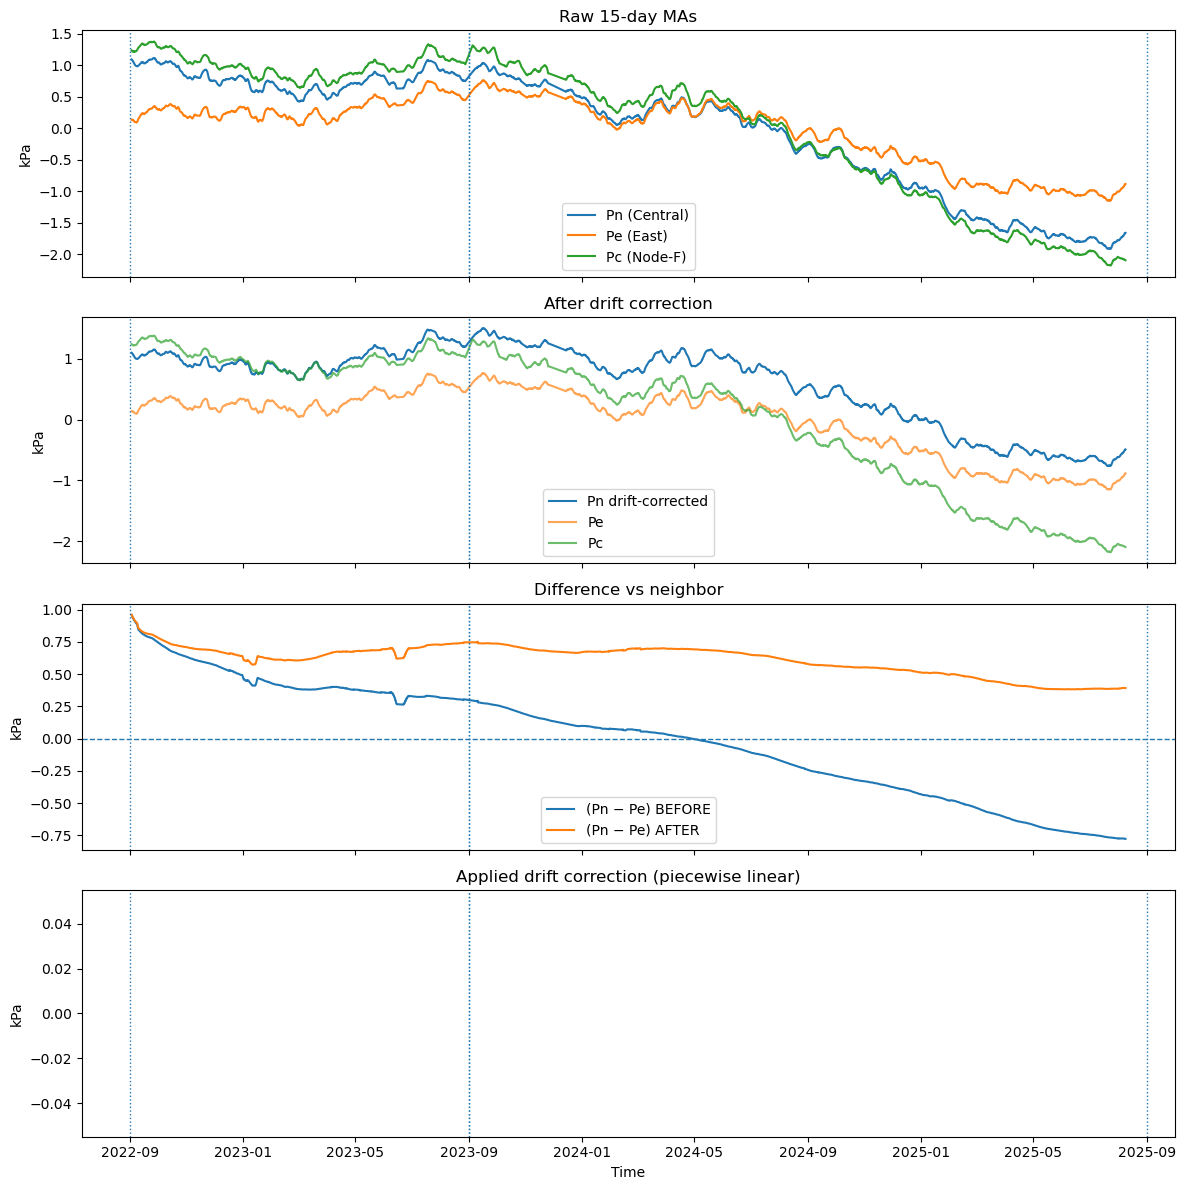

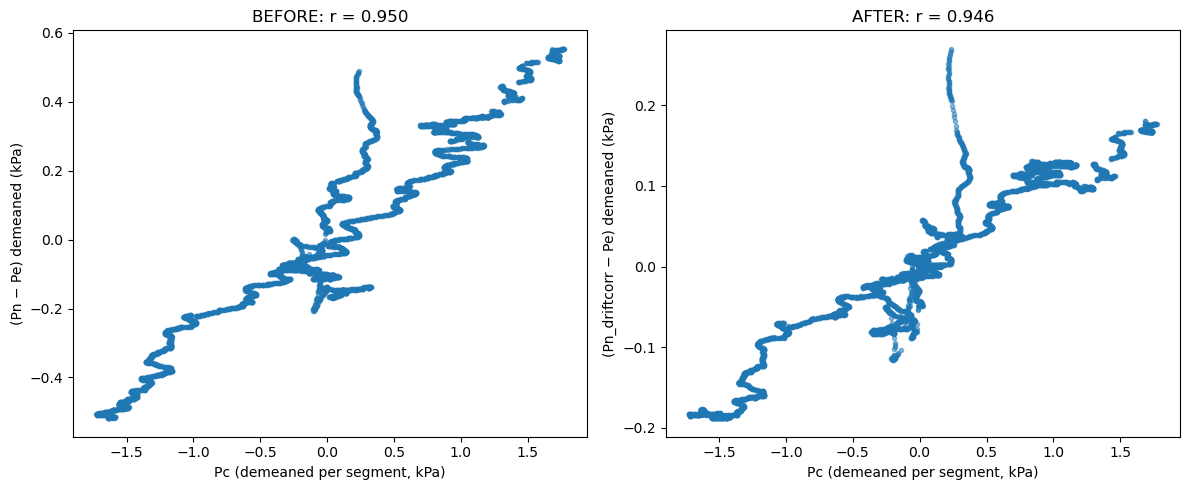

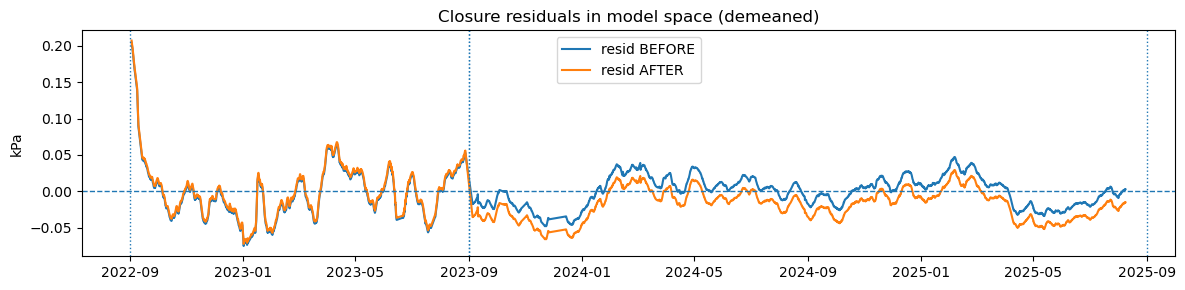


Drift re-fit on corrected Pn (expect |c| ≈ 0):
   seg_start    seg_end             c  drift_kPa_per_year         b  rmse_kPa  \
0 2022-09-01 2023-09-01  0.000000e+00        0.000000e+00  0.280141   0.03903   
1 2023-09-01 2025-09-01  1.387779e-17        5.068862e-15  0.109923   0.01987   

      n  
0  2024  
1  3887  


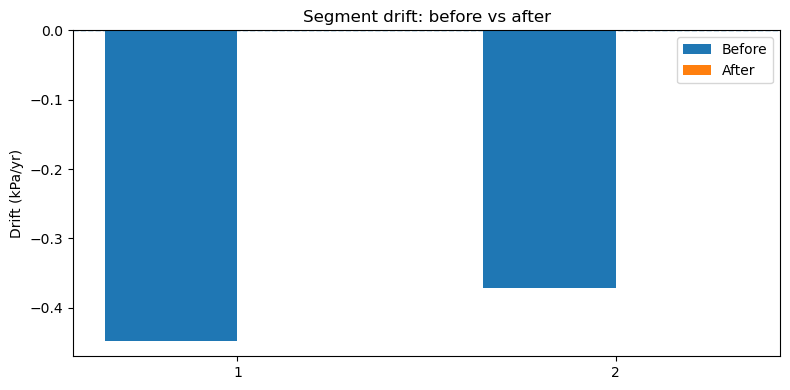

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------- helpers --------------------
def segment_id(times, segments):
    """Return an int index per timestamp for which segment it falls in."""
    seg_idx = np.full(len(times), -1, dtype=int)
    for i, (s, e) in enumerate(segments):
        s = pd.Timestamp(s); e = pd.Timestamp(e)
        seg_idx[(times >= s) & (times < e)] = i
    return seg_idx

def model_yhat(df, segments, fits):
    """
    Reconstruct the modeled (demeaned) difference:
      Yhat_before = a + b*X + c*t'   with X=(Pc - meanPc_seg), t'=(t - t_mid) in days
      Yhat_after  = a + b*X          (since c*t' is removed by the correction)
    Also returns Y_before, Y_after (both demeaned per segment).
    """
    out = df.copy()
    out["seg"] = segment_id(out["time"].values, segments)

    # Precompute per-segment means
    seg_means = []
    for i, (s, e) in enumerate(segments):
        mask = out["seg"] == i
        seg_means.append({
            "i": i,
            "mean_diff_before": (out.loc[mask, "Pn"] - out.loc[mask, "Pe"]).mean(),
            "mean_diff_after" : (out.loc[mask, "Pn_driftcorr"] - out.loc[mask, "Pe"]).mean(),
            "mean_Pc": out.loc[mask, "Pc"].mean(),
        })

    # Build arrays
    Y_before = np.empty(len(out)); Y_after = np.empty(len(out))
    X = np.empty(len(out)); tprime_days = np.empty(len(out))
    Yhat_before = np.empty(len(out)); Yhat_after = np.empty(len(out))

    for i, (s, e) in enumerate(segments):
        mask = out["seg"] == i
        if not mask.any():
            continue

        f = fits[i]  # dict with a,b,c,t_mid
        mean_diff_b = seg_means[i]["mean_diff_before"]
        mean_diff_a = seg_means[i]["mean_diff_after"]
        mean_pc     = seg_means[i]["mean_Pc"]

        # Demeaned quantities to match the regression space used earlier
        Yb = (out.loc[mask, "Pn"] - out.loc[mask, "Pe"]) - mean_diff_b
        Ya = (out.loc[mask, "Pn_driftcorr"] - out.loc[mask, "Pe"]) - mean_diff_a
        Xs = out.loc[mask, "Pc"] - mean_pc
        td = (out.loc[mask, "time"] - f["t_mid"]).dt.total_seconds() / 86400.0

        # Modeled (demeaned) before/after
        Yhb = f["a"] + f["b"] * Xs + f["c"] * td
        Yha = f["a"] + f["b"] * Xs  # no c*t' after correction

        # write back
        Y_before[mask]    = Yb.values
        Y_after[mask]     = Ya.values
        X[mask]           = Xs.values
        tprime_days[mask] = td.values
        Yhat_before[mask] = Yhb.values
        Yhat_after[mask]  = Yha.values

    out["Y_before"] = Y_before
    out["Y_after"]  = Y_after
    out["X_Pc_dm"]  = X
    out["tprime_d"] = tprime_days
    out["Yhat_before"] = Yhat_before
    out["Yhat_after"]  = Yhat_after
    out["resid_before"] = out["Y_before"] - out["Yhat_before"]
    out["resid_after"]  = out["Y_after"]  - out["Yhat_after"]
    return out

def refit_drift_on_corrected(merged, segments, min_pts=25):
    """
    Repeat the same regression but with Pn replaced by Pn_driftcorr
    to see if the linear drift term c collapses toward 0 in each segment.
    """
    def fit_seg(df_seg):
        dPn = df_seg["Pn_driftcorr"] - df_seg["Pn_driftcorr"].mean()
        dPe = df_seg["Pe"]           - df_seg["Pe"].mean()
        dPc = df_seg["Pc"]           - df_seg["Pc"].mean()
        Y = (dPn - dPe).to_numpy(float)
        X = dPc.to_numpy(float)
        t_mid = df_seg["time"].iloc[0] + (df_seg["time"].iloc[-1] - df_seg["time"].iloc[0]) / 2
        t_days = (df_seg["time"] - t_mid).dt.total_seconds().to_numpy() / 86400.0
        A = np.column_stack([np.ones_like(X), X, t_days])
        a, b, c = np.linalg.lstsq(A, Y, rcond=None)[0]
        rmse = float(np.sqrt(np.mean((Y - A @ np.array([a,b,c]))**2)))
        return {"a":float(a), "b":float(b), "c":float(c), "rmse_kPa":rmse, "t_mid":t_mid, "n":len(df_seg)}

    rows=[]
    for s,e in segments:
        mask = (merged["time"]>=pd.Timestamp(s)) & (merged["time"]<pd.Timestamp(e))
        seg = merged.loc[mask].copy()
        if len(seg) >= min_pts:
            rows.append({**fit_seg(seg), "seg_start":pd.Timestamp(s), "seg_end":pd.Timestamp(e)})
    return pd.DataFrame(rows)

# -------------------- build evaluation frame --------------------
# Safety: ensure datetime naive and sorted
merged = merged.copy()
merged["time"] = pd.to_datetime(merged["time"], errors="coerce")
try:
    merged["time"] = merged["time"].dt.tz_convert(None)
except Exception:
    try:
        merged["time"] = merged["time"].dt.tz_localize(None)
    except Exception:
        pass
merged = merged.dropna(subset=["time"]).sort_values("time")

eval_df = model_yhat(merged, segments_norm, fits_list)

# -------------------- 1) time-series dashboard --------------------
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# (a) Pn, Pe, Pc
axes[0].plot(merged["time"], merged["Pn"], label="Pn (Central)")
axes[0].plot(merged["time"], merged["Pe"], label="Pe (East)")
axes[0].plot(merged["time"], merged["Pc"], label="Pc (Node-F)")
axes[0].set_ylabel("kPa"); axes[0].legend(loc="best"); axes[0].set_title("Raw 15-day MAs")

# (b) corrected Pn vs Pe/Pc
axes[1].plot(merged["time"], merged["Pn_driftcorr"], label="Pn drift-corrected")
axes[1].plot(merged["time"], merged["Pe"], alpha=0.7, label="Pe")
axes[1].plot(merged["time"], merged["Pc"], alpha=0.7, label="Pc")
axes[1].set_ylabel("kPa"); axes[1].legend(loc="best"); axes[1].set_title("After drift correction")

# (c) (Pn-Pe) before/after
axes[2].plot(merged["time"], (merged["Pn"] - merged["Pe"]), label="(Pn − Pe) BEFORE")
axes[2].plot(merged["time"], (merged["Pn_driftcorr"] - merged["Pe"]), label="(Pn − Pe) AFTER")
axes[2].axhline(0, ls="--", lw=1)
axes[2].set_ylabel("kPa"); axes[2].legend(loc="best"); axes[2].set_title("Difference vs neighbor")

# (d) applied correction series (rebuild if you saved it separately)
# If you kept 'corr' from earlier, use it; otherwise reconstruct from fits_list for plotting only:
try:
    corr_series = corr.reindex(merged["time"]).to_numpy()
except Exception:
    # minimal reconstruction: linear pieces with continuity
    def quick_corr(times, segments, fits):
        out = pd.Series(0.0, index=times)
        base = 0.0
        for (s,e), f in zip(segments, fits):
            s = pd.Timestamp(s); e=pd.Timestamp(e)
            m = (times>=s)&(times<e)
            td = (times[m] - f["t_mid"]).dt.total_seconds()/86400.0
            start_val = f["c"]*((s - f["t_mid"]).total_seconds()/86400.0)
            end_val   = f["c"]*((e - f["t_mid"]).total_seconds()/86400.0)
            out.loc[m] = f["c"]*td + (base - start_val)
            base = base + (end_val - start_val)
        return out
    corr_series = quick_corr(merged["time"], segments_norm, fits_list).to_numpy()

axes[3].plot(merged["time"], corr_series)
axes[3].set_ylabel("kPa"); axes[3].set_title("Applied drift correction (piecewise linear)")
axes[3].set_xlabel("Time")

# Segment markers
for ax in axes:
    for s, e in segments_norm:
        ax.axvline(pd.Timestamp(s), ls=":", lw=1)
        ax.axvline(pd.Timestamp(e), ls=":", lw=1)
plt.tight_layout(); plt.show()

# -------------------- 2) cross-plots vs Pc --------------------
# Demean per segment to match regression space
def demean_by_segment(vals, seg_ids):
    out = np.empty_like(vals, dtype=float)
    for i in np.unique(seg_ids):
        m = (seg_ids==i)
        out[m] = vals[m] - np.nanmean(vals[m])
    return out

seg_ids = segment_id(eval_df["time"].values, segments_norm)
xb = eval_df["X_Pc_dm"].to_numpy()
yb = eval_df["Y_before"].to_numpy()
ya = eval_df["Y_after"].to_numpy()

r_before = np.corrcoef(xb, yb)[0,1]
r_after  = np.corrcoef(xb, ya)[0,1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
ax1.plot(xb, yb, '.', alpha=0.5)
ax1.set_xlabel("Pc (demeaned per segment, kPa)")
ax1.set_ylabel("(Pn − Pe) demeaned (kPa)")
ax1.set_title(f"BEFORE: r = {r_before:.3f}")

ax2.plot(xb, ya, '.', alpha=0.5)
ax2.set_xlabel("Pc (demeaned per segment, kPa)")
ax2.set_ylabel("(Pn_driftcorr − Pe) demeaned (kPa)")
ax2.set_title(f"AFTER: r = {r_after:.3f}")
plt.tight_layout(); plt.show()

# -------------------- 3) residual time series (model space) --------------------
fig, ax = plt.subplots(figsize=(12,3))
ax.plot(eval_df["time"], eval_df["resid_before"], label="resid BEFORE")
ax.plot(eval_df["time"], eval_df["resid_after"],  label="resid AFTER")
ax.axhline(0, ls="--", lw=1)
ax.set_ylabel("kPa"); ax.set_title("Closure residuals in model space (demeaned)")
for s,e in segments_norm:
    ax.axvline(pd.Timestamp(s), ls=":", lw=1)
    ax.axvline(pd.Timestamp(e), ls=":", lw=1)
ax.legend(); plt.tight_layout(); plt.show()

# -------------------- 4) re-fit on corrected data → drift should collapse --------------------
refit_df = refit_drift_on_corrected(merged, segments_norm, min_pts=25)
if not refit_df.empty:
    print("\nDrift re-fit on corrected Pn (expect |c| ≈ 0):")
    refit_df["drift_kPa_per_year"] = refit_df["c"] * 365.25
    print(refit_df[["seg_start","seg_end","c","drift_kPa_per_year","b","rmse_kPa","n"]])

    # simple bar plot of drift before/after
    # collect 'before' from your original fits_list:
    before_per_year = [f["c"]*365.25 for f in fits_list]
    after_per_year  = refit_df["drift_kPa_per_year"].to_list()

    x = np.arange(len(before_per_year))
    width = 0.35
    fig, ax = plt.subplots(figsize=(8,4))
    ax.bar(x - width/2, before_per_year, width, label="Before")
    ax.bar(x + width/2, after_per_year,  width, label="After")
    ax.set_xticks(x); ax.set_xticklabels([f"{i+1}" for i in x])
    ax.set_ylabel("Drift (kPa/yr)"); ax.set_title("Segment drift: before vs after")
    ax.axhline(0, ls="--", lw=1); ax.legend()
    plt.tight_layout(); plt.show()


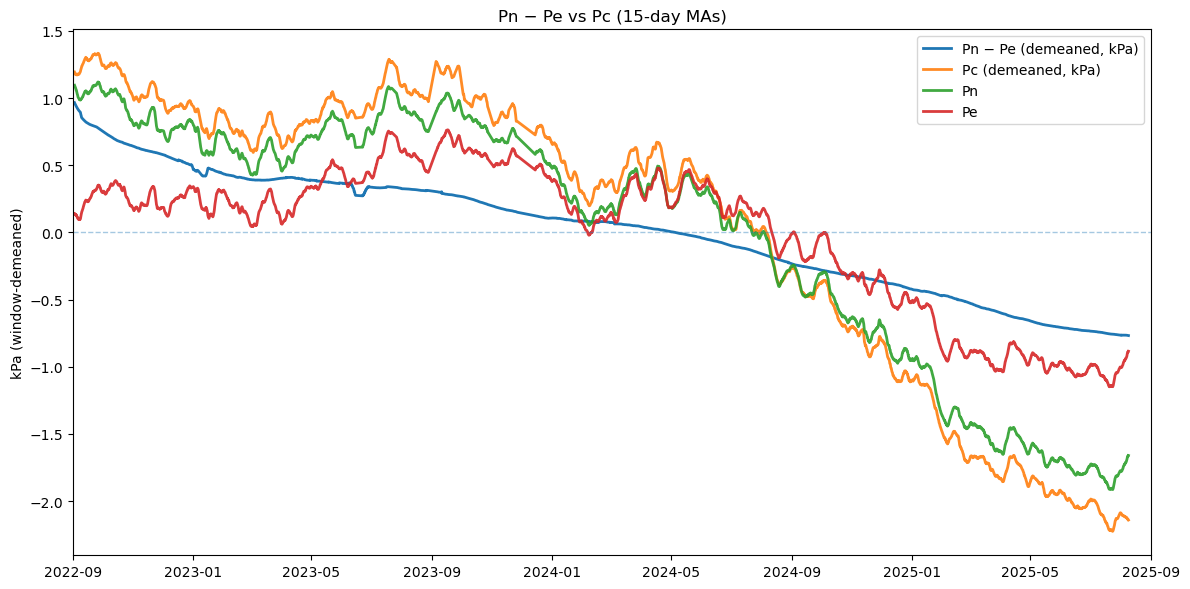

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# edit as needed
start = pd.Timestamp('2022-09-01')
end   = pd.Timestamp('2025-09-01')

def asof_merge(ma_pn, ma_pe, ma_pc, tol="2H"):
    """Align Pn (ma_pn), Pe (ma_pe), Pc (ma_pc) onto Pn's timeline."""
    def s2df(s, name):
        s = s.dropna()
        s.index = pd.to_datetime(s.index, errors="coerce")
        s = s[~s.index.isna()]
        df = s.rename(name).rename_axis("time").reset_index()
        # normalize tz if present
        try:
            df["time"] = df["time"].dt.tz_convert(None)
        except Exception:
            try:
                df["time"] = df["time"].dt.tz_localize(None)
            except Exception:
                pass
        df = df.sort_values("time")
        df = df[~df["time"].duplicated(keep="first")]
        return df

    pn = s2df(ma_c,  "Pn")
    pe = s2df(ma_e,  "Pe")
    pc = s2df(ma_cp, "Pc")

    m = pd.merge_asof(pn, pe, on="time", direction="nearest",
                      tolerance=pd.Timedelta(tol))
    m = pd.merge_asof(m.dropna(subset=["Pe"]).sort_values("time"),
                      pc, on="time", direction="nearest",
                      tolerance=pd.Timedelta(tol))
    return m.dropna(subset=["Pe","Pc"]).sort_values("time").reset_index(drop=True)

# align & window
merged = asof_merge(ma_c, ma_e, ma_cp, tol="2H")
sub = merged[(merged["time"] >= start) & (merged["time"] <= end)].copy()

# build the two series
sub["Pn_minus_Pe"] = sub["Pn"] - sub["Pe"]
pnpe = sub["Pn_minus_Pe"] - sub["Pn_minus_Pe"].mean()   # demean for clean compare
pc0  = sub["Pc"] - sub["Pc"].mean()

# --- plot: two time series on same axis ---
plt.figure(figsize=(12,6))
plt.plot(sub["time"], pnpe,  lw=2, label="Pn − Pe (demeaned, kPa)")
plt.plot(sub["time"], pc0,   lw=2, label="Pc (demeaned, kPa)", alpha=0.9)
plt.plot(sub["time"], sub["Pn"],   lw=2, label="Pn", alpha=0.9)
plt.plot(sub["time"], sub["Pe"],   lw=2, label="Pe", alpha=0.9)
plt.axhline(0, ls="--", lw=1, alpha=0.4)
plt.xlim(start, end)
plt.ylabel("kPa (window-demeaned)")
plt.title("Pn − Pe vs Pc (15-day MAs)")
plt.legend()
plt.tight_layout()
plt.show()


In [53]:
merged

,time,Pn,Pe,Pc,ep,wp,Pw
0,2022-09-02 11:45:00,1.095798,0.138377,1.239792,0.460075,0.790799,0.031013
1,2022-09-02 15:45:00,1.091382,0.136863,1.237164,0.455984,0.783918,0.028472
2,2022-09-02 19:45:00,1.090272,0.137985,1.233158,0.452847,0.776999,0.029013
3,2022-09-02 23:45:00,1.087256,0.137780,1.232530,0.452567,0.776589,0.026985
4,2022-09-03 03:45:00,1.080262,0.133974,1.227207,0.447329,0.775699,0.021814
...,...,...,...,...,...,...,...
5595,2025-08-08 11:45:00,-1.668661,-0.893197,-2.089228,-0.665661,-1.198759,-0.683842
5596,2025-08-08 15:45:00,-1.663038,-0.887394,-2.090482,-0.666406,-1.202028,-0.683635
5597,2025-08-08 19:45:00,-1.663931,-0.887764,-2.090296,-0.666047,-1.203368,-0.685628
5598,2025-08-08 23:45:00,-1.663927,-0.887646,-2.092537,-0.667576,-1.204395,-0.687816



Pn model over 2023-09 to 2025-09
a_n (kPa)         = -0.4499
b_n (kPa/kPa)     = 0.8918   # Pc coupling
c_n (kPa/yr)      = 0.1025   # linear drift rate
RMSE (kPa)        = 0.0298
N (15d-MA points) = 3887


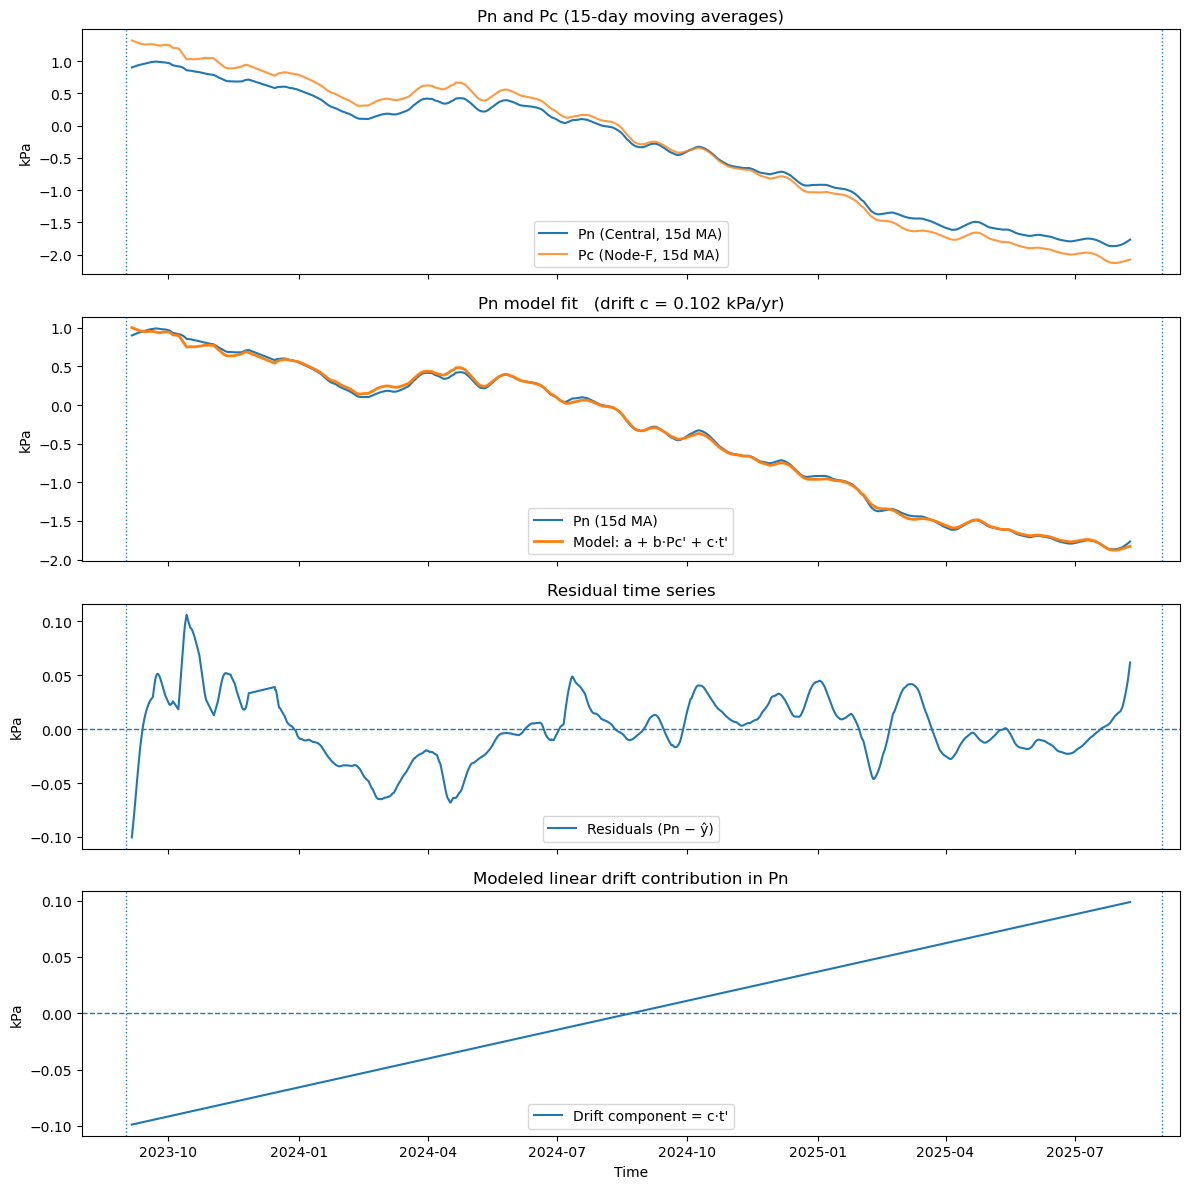

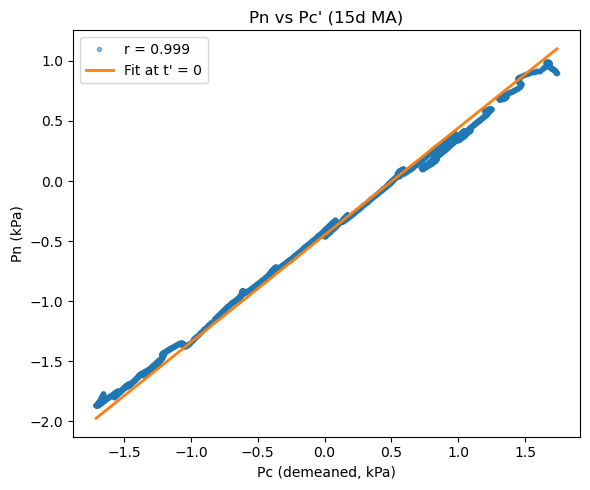

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------- 0) window + prep -----------
t0 = pd.Timestamp('2023-09-01')
t1 = pd.Timestamp('2025-09-01')

df = merged.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")
try:
    df["time"] = df["time"].dt.tz_convert(None)
except Exception:
    try:
        df["time"] = df["time"].dt.tz_localize(None)
    except Exception:
        pass
df = df.dropna(subset=["time", "Pn", "Pc"]).sort_values("time")
df = df[(df["time"] >= t0) & (df["time"] < t1)].copy()

if df.empty:
    raise ValueError("Pn model window has no data after filtering.")

# 15-day moving average (time-based) to match your style
tmp = df.set_index("time").sort_index()
ma = tmp[["Pn", "Pc"]].rolling("15D").mean()
ma = ma.dropna().copy()
ma["time"] = ma.index

# ----------- 1) build regressors (Pc' and t' in years) -----------
Pc_mean = ma["Pc"].mean()
ma["Pc_dm"] = ma["Pc"] - Pc_mean

t_mid = ma.index[0] + (ma.index[-1] - ma.index[0]) / 2
ma["tprime_years"] = (ma.index - t_mid).total_seconds() / (365.25 * 86400.0)

# ----------- 2) fit Pn ~ 1 + Pc' + t' -----------
y = ma["Pn"].to_numpy(float)
A = np.column_stack([
    np.ones(len(ma)), 
    ma["Pc_dm"].to_numpy(float), 
    ma["tprime_years"].to_numpy(float)
])
coef, *_ = np.linalg.lstsq(A, y, rcond=None)
a_n, b_n, c_n = coef  # c_n is kPa/year since t' is in years

ma["Pn_hat"] = A @ coef
ma["resid"]  = y - ma["Pn_hat"]
ma["drift_component"] = c_n * ma["tprime_years"]  # kPa contribution from drift

print("\nPn model over 2023-09 to 2025-09")
print(f"a_n (kPa)         = {a_n:.4f}")
print(f"b_n (kPa/kPa)     = {b_n:.4f}   # Pc coupling")
print(f"c_n (kPa/yr)      = {c_n:.4f}   # linear drift rate")
print(f"RMSE (kPa)        = {np.sqrt(np.mean(ma['resid']**2)):.4f}")
print(f"N (15d-MA points) = {len(ma)}")

# ----------- 3) plots (similar style) -----------
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# (a) 15-day MAs: Pn and Pc
axes[0].plot(ma["time"], ma["Pn"], label="Pn (Central, 15d MA)")
axes[0].plot(ma["time"], ma["Pc"], label="Pc (Node-F, 15d MA)", alpha=0.8)
axes[0].set_ylabel("kPa"); axes[0].legend(loc="best"); 
axes[0].set_title("Pn and Pc (15-day moving averages)")

# (b) Pn vs model fit
axes[1].plot(ma["time"], ma["Pn"], label="Pn (15d MA)")
axes[1].plot(ma["time"], ma["Pn_hat"], label="Model: a + b·Pc' + c·t'", linewidth=2)
axes[1].set_ylabel("kPa"); axes[1].legend(loc="best")
axes[1].set_title(f"Pn model fit   (drift c = {c_n:.3f} kPa/yr)")

# (c) residuals
axes[2].plot(ma["time"], ma["resid"], label="Residuals (Pn − ŷ)")
axes[2].axhline(0, ls="--", lw=1)
axes[2].set_ylabel("kPa"); axes[2].legend(loc="best")
axes[2].set_title("Residual time series")

# (d) isolated drift component (c·t')
axes[3].plot(ma["time"], ma["drift_component"], label="Drift component = c·t'")
axes[3].axhline(0, ls="--", lw=1)
axes[3].set_ylabel("kPa"); axes[3].set_xlabel("Time"); axes[3].legend(loc="best")
axes[3].set_title("Modeled linear drift contribution in Pn")

# window markers
for ax in axes:
    ax.axvline(t0, ls=":", lw=1)
    ax.axvline(t1, ls=":", lw=1)

plt.tight_layout(); plt.show()

# ----------- 4) quick cross-plot: Pc' vs Pn (with fit line) -----------
r = np.corrcoef(ma["Pc_dm"], ma["Pn"])[0,1]
plt.figure(figsize=(6,5))
plt.plot(ma["Pc_dm"], ma["Pn"], '.', alpha=0.5, label=f"r = {r:.3f}")
# draw model slice at t'=0 so line shows Pc' coupling only
xg = np.linspace(ma["Pc_dm"].min(), ma["Pc_dm"].max(), 200)
yg = a_n + b_n * xg  # at t'=0
plt.plot(xg, yg, lw=2, label="Fit at t' = 0")
plt.xlabel("Pc (demeaned, kPa)"); plt.ylabel("Pn (kPa)")
plt.title("Pn vs Pc' (15d MA)"); plt.legend(); plt.tight_layout(); plt.show()



Pe model over 2023-09 to 2025-09
a_n (kPa)         = -0.2720
b_n (kPa/kPa)     = 0.7768   # Pc coupling
c_n (kPa/yr)      = 0.4627   # linear drift rate
RMSE (kPa)        = 0.0376
N (15d-MA points) = 3599


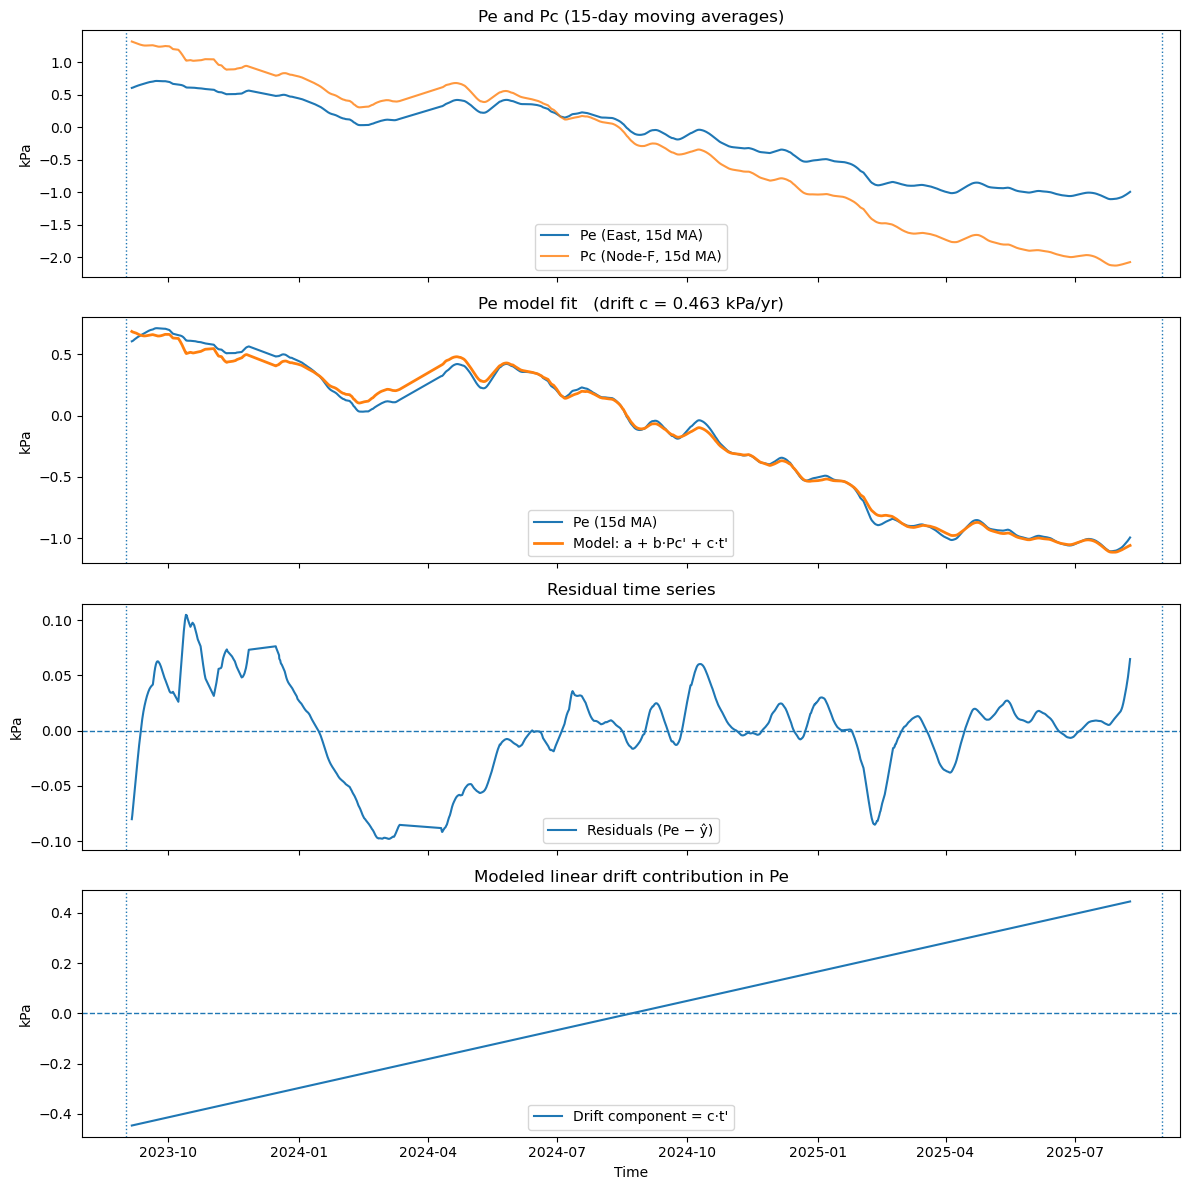

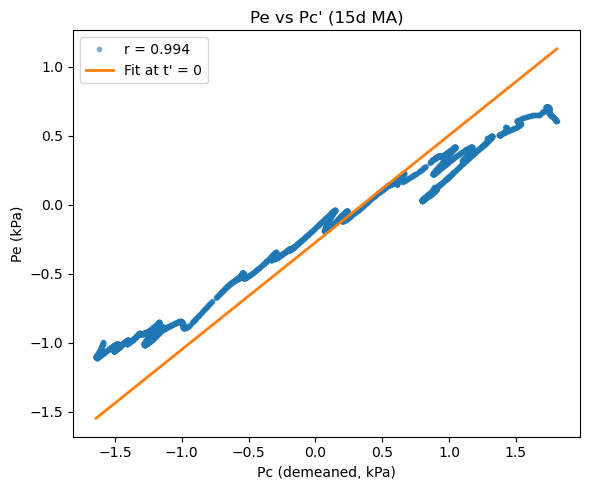

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------- 0) window + prep -----------
t0 = pd.Timestamp('2023-09-01')
t1 = pd.Timestamp('2025-09-01')

df = merged.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")
try:
    df["time"] = df["time"].dt.tz_convert(None)
except Exception:
    try:
        df["time"] = df["time"].dt.tz_localize(None)
    except Exception:
        pass
df = df.dropna(subset=["time", "Pe", "Pc"]).sort_values("time")
df = df[(df["time"] >= t0) & (df["time"] < t1)].copy()

if df.empty:
    raise ValueError("Pe model window has no data after filtering.")

# 15-day moving average (time-based) to match your style
tmp = df.set_index("time").sort_index()
ma = tmp[["Pe", "Pc"]].rolling("15D").mean()
ma = ma.dropna().copy()
ma["time"] = ma.index

# ----------- 1) build regressors (Pc' and t' in years) -----------
Pc_mean = ma["Pc"].mean()
ma["Pc_dm"] = ma["Pc"] - Pc_mean

t_mid = ma.index[0] + (ma.index[-1] - ma.index[0]) / 2
ma["tprime_years"] = (ma.index - t_mid).total_seconds() / (365.25 * 86400.0)

# ----------- 2) fit Pe ~ 1 + Pc' + t' -----------
y = ma["Pe"].to_numpy(float)
A = np.column_stack([
    np.ones(len(ma)), 
    ma["Pc_dm"].to_numpy(float), 
    ma["tprime_years"].to_numpy(float)
])
coef, *_ = np.linalg.lstsq(A, y, rcond=None)
a_n, b_n, c_n = coef  # c_n is kPa/year since t' is in years

ma["Pe_hat"] = A @ coef
ma["resid"]  = y - ma["Pe_hat"]
ma["drift_component"] = c_n * ma["tprime_years"]  # kPa contribution from drift

print("\nPe model over 2023-09 to 2025-09")
print(f"a_n (kPa)         = {a_n:.4f}")
print(f"b_n (kPa/kPa)     = {b_n:.4f}   # Pc coupling")
print(f"c_n (kPa/yr)      = {c_n:.4f}   # linear drift rate")
print(f"RMSE (kPa)        = {np.sqrt(np.mean(ma['resid']**2)):.4f}")
print(f"N (15d-MA points) = {len(ma)}")

# ----------- 3) plots (similar style) -----------
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# (a) 15-day MAs: Pe and Pc
axes[0].plot(ma["time"], ma["Pe"], label="Pe (East, 15d MA)")
axes[0].plot(ma["time"], ma["Pc"], label="Pc (Node-F, 15d MA)", alpha=0.8)
axes[0].set_ylabel("kPa"); axes[0].legend(loc="best"); 
axes[0].set_title("Pe and Pc (15-day moving averages)")

# (b) Pe vs model fit
axes[1].plot(ma["time"], ma["Pe"], label="Pe (15d MA)")
axes[1].plot(ma["time"], ma["Pe_hat"], label="Model: a + b·Pc' + c·t'", linewidth=2)
axes[1].set_ylabel("kPa"); axes[1].legend(loc="best")
axes[1].set_title(f"Pe model fit   (drift c = {c_n:.3f} kPa/yr)")

# (c) residuals
axes[2].plot(ma["time"], ma["resid"], label="Residuals (Pe − ŷ)")
axes[2].axhline(0, ls="--", lw=1)
axes[2].set_ylabel("kPa"); axes[2].legend(loc="best")
axes[2].set_title("Residual time series")

# (d) isolated drift component (c·t')
axes[3].plot(ma["time"], ma["drift_component"], label="Drift component = c·t'")
axes[3].axhline(0, ls="--", lw=1)
axes[3].set_ylabel("kPa"); axes[3].set_xlabel("Time"); axes[3].legend(loc="best")
axes[3].set_title("Modeled linear drift contribution in Pe")

# window markers
for ax in axes:
    ax.axvline(t0, ls=":", lw=1)
    ax.axvline(t1, ls=":", lw=1)

plt.tight_layout(); plt.show()

# ----------- 4) quick cross-plot: Pc' vs Pn (with fit line) -----------
r = np.corrcoef(ma["Pc_dm"], ma["Pe"])[0,1]
plt.figure(figsize=(6,5))
plt.plot(ma["Pc_dm"], ma["Pe"], '.', alpha=0.5, label=f"r = {r:.3f}")
# draw model slice at t'=0 so line shows Pc' coupling only
xg = np.linspace(ma["Pc_dm"].min(), ma["Pc_dm"].max(), 200)
yg = a_n + b_n * xg  # at t'=0
plt.plot(xg, yg, lw=2, label="Fit at t' = 0")
plt.xlabel("Pc (demeaned, kPa)"); plt.ylabel("Pe (kPa)")
plt.title("Pe vs Pc' (15d MA)"); plt.legend(); plt.tight_layout(); plt.show()



Pw model over 2023-09 to 2025-09
a_n (kPa)         = -0.1693
b_n (kPa/kPa)     = 0.7550   # Pc coupling
c_n (kPa/yr)      = 0.6795   # linear drift rate
RMSE (kPa)        = 0.0463
N (15d-MA points) = 3599


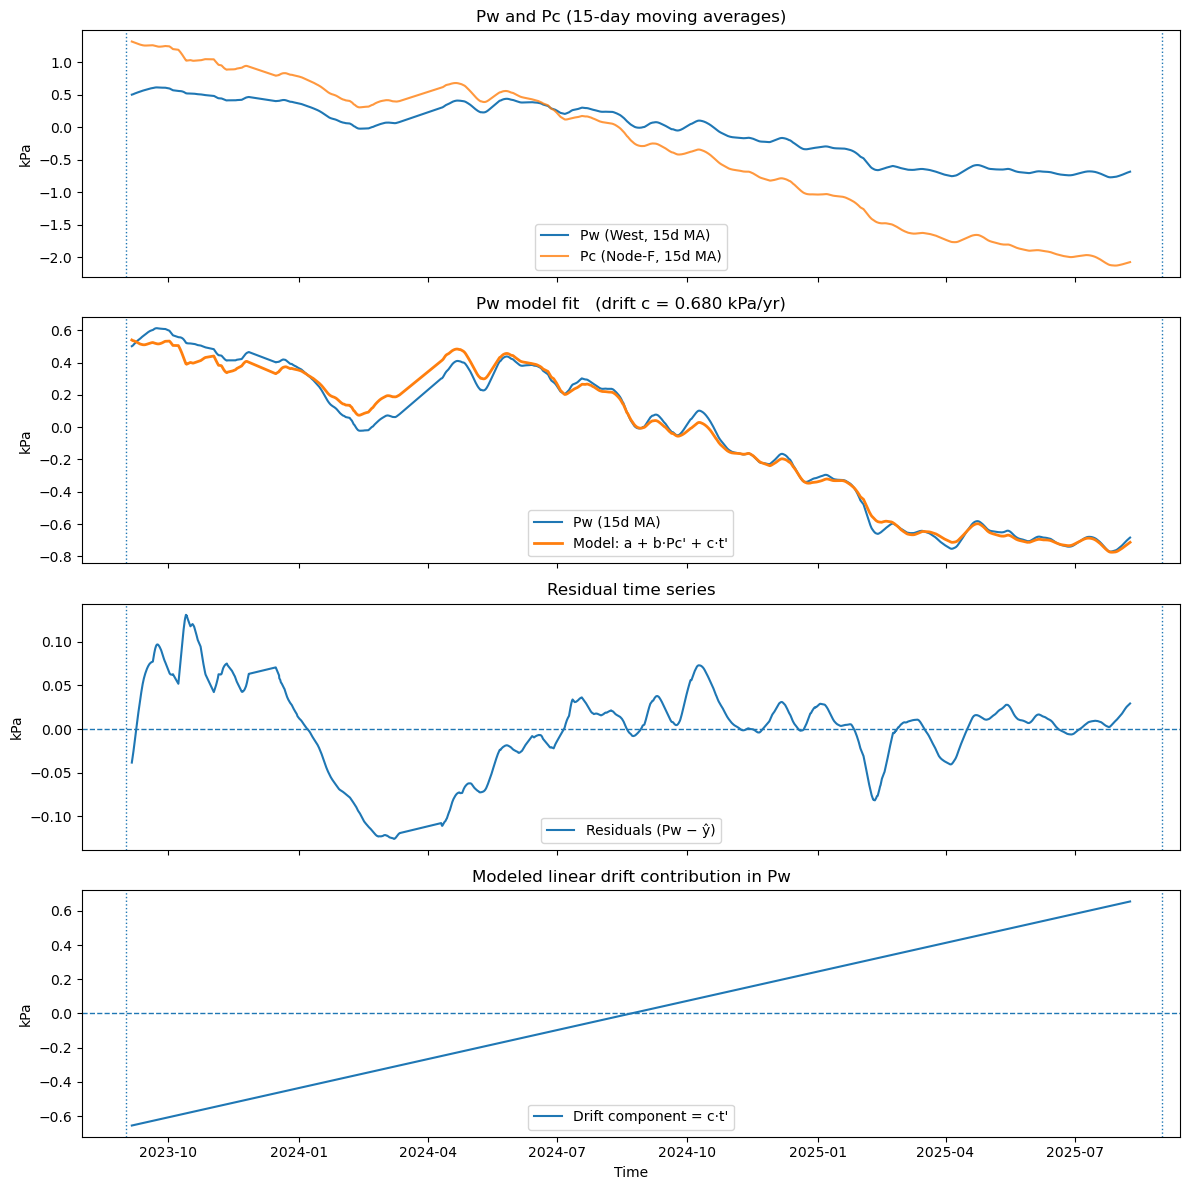

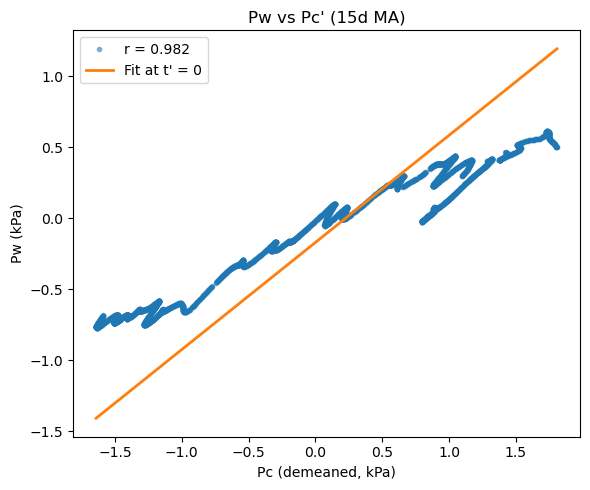

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------- 0) window + prep -----------
t0 = pd.Timestamp('2023-09-01')
t1 = pd.Timestamp('2025-09-01')

df = merged.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")
try:
    df["time"] = df["time"].dt.tz_convert(None)
except Exception:
    try:
        df["time"] = df["time"].dt.tz_localize(None)
    except Exception:
        pass
df = df.dropna(subset=["time", "Pw", "Pc"]).sort_values("time")
df = df[(df["time"] >= t0) & (df["time"] < t1)].copy()

if df.empty:
    raise ValueError("Pw model window has no data after filtering.")

# 15-day moving average (time-based) to match your style
tmp = df.set_index("time").sort_index()
ma = tmp[["Pw", "Pc"]].rolling("15D").mean()
ma = ma.dropna().copy()
ma["time"] = ma.index

# ----------- 1) build regressors (Pc' and t' in years) -----------
Pc_mean = ma["Pc"].mean()
ma["Pc_dm"] = ma["Pc"] - Pc_mean

t_mid = ma.index[0] + (ma.index[-1] - ma.index[0]) / 2
ma["tprime_years"] = (ma.index - t_mid).total_seconds() / (365.25 * 86400.0)

# ----------- 2) fit Pw ~ 1 + Pc' + t' -----------
y = ma["Pw"].to_numpy(float)
A = np.column_stack([
    np.ones(len(ma)), 
    ma["Pc_dm"].to_numpy(float), 
    ma["tprime_years"].to_numpy(float)
])
coef, *_ = np.linalg.lstsq(A, y, rcond=None)
a_n, b_n, c_n = coef  # c_n is kPa/year since t' is in years

ma["Pw_hat"] = A @ coef
ma["resid"]  = y - ma["Pw_hat"]
ma["drift_component"] = c_n * ma["tprime_years"]  # kPa contribution from drift

print("\nPw model over 2023-09 to 2025-09")
print(f"a_n (kPa)         = {a_n:.4f}")
print(f"b_n (kPa/kPa)     = {b_n:.4f}   # Pc coupling")
print(f"c_n (kPa/yr)      = {c_n:.4f}   # linear drift rate")
print(f"RMSE (kPa)        = {np.sqrt(np.mean(ma['resid']**2)):.4f}")
print(f"N (15d-MA points) = {len(ma)}")

# ----------- 3) plots (similar style) -----------
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# (a) 15-day MAs: Pw and Pc
axes[0].plot(ma["time"], ma["Pw"], label="Pw (West, 15d MA)")
axes[0].plot(ma["time"], ma["Pc"], label="Pc (Node-F, 15d MA)", alpha=0.8)
axes[0].set_ylabel("kPa"); axes[0].legend(loc="best"); 
axes[0].set_title("Pw and Pc (15-day moving averages)")

# (b) Pw vs model fit
axes[1].plot(ma["time"], ma["Pw"], label="Pw (15d MA)")
axes[1].plot(ma["time"], ma["Pw_hat"], label="Model: a + b·Pc' + c·t'", linewidth=2)
axes[1].set_ylabel("kPa"); axes[1].legend(loc="best")
axes[1].set_title(f"Pw model fit   (drift c = {c_n:.3f} kPa/yr)")

# (c) residuals
axes[2].plot(ma["time"], ma["resid"], label="Residuals (Pw − ŷ)")
axes[2].axhline(0, ls="--", lw=1)
axes[2].set_ylabel("kPa"); axes[2].legend(loc="best")
axes[2].set_title("Residual time series")

# (d) isolated drift component (c·t')
axes[3].plot(ma["time"], ma["drift_component"], label="Drift component = c·t'")
axes[3].axhline(0, ls="--", lw=1)
axes[3].set_ylabel("kPa"); axes[3].set_xlabel("Time"); axes[3].legend(loc="best")
axes[3].set_title("Modeled linear drift contribution in Pw")

# window markers
for ax in axes:
    ax.axvline(t0, ls=":", lw=1)
    ax.axvline(t1, ls=":", lw=1)

plt.tight_layout(); plt.show()

# ----------- 4) quick cross-plot: Pc' vs Pn (with fit line) -----------
r = np.corrcoef(ma["Pc_dm"], ma["Pw"])[0,1]
plt.figure(figsize=(6,5))
plt.plot(ma["Pc_dm"], ma["Pw"], '.', alpha=0.5, label=f"r = {r:.3f}")
# draw model slice at t'=0 so line shows Pc' coupling only
xg = np.linspace(ma["Pc_dm"].min(), ma["Pc_dm"].max(), 200)
yg = a_n + b_n * xg  # at t'=0
plt.plot(xg, yg, lw=2, label="Fit at t' = 0")
plt.xlabel("Pc (demeaned, kPa)"); plt.ylabel("Pw (kPa)")
plt.title("Pw vs Pc' (15d MA)"); plt.legend(); plt.tight_layout(); plt.show()



Pe drift model over 2023-09 to 2025-09 (ep = drift-free reference)
a_e (kPa)         = -0.2037
b_e (kPa/kPa)     = 0.9545   # coupling to ep (drift-free)
c_e (kPa/yr)      = -0.3469   # Pe linear drift rate
RMSE (kPa)        = 0.0578
N (15d-MA points) = 3599


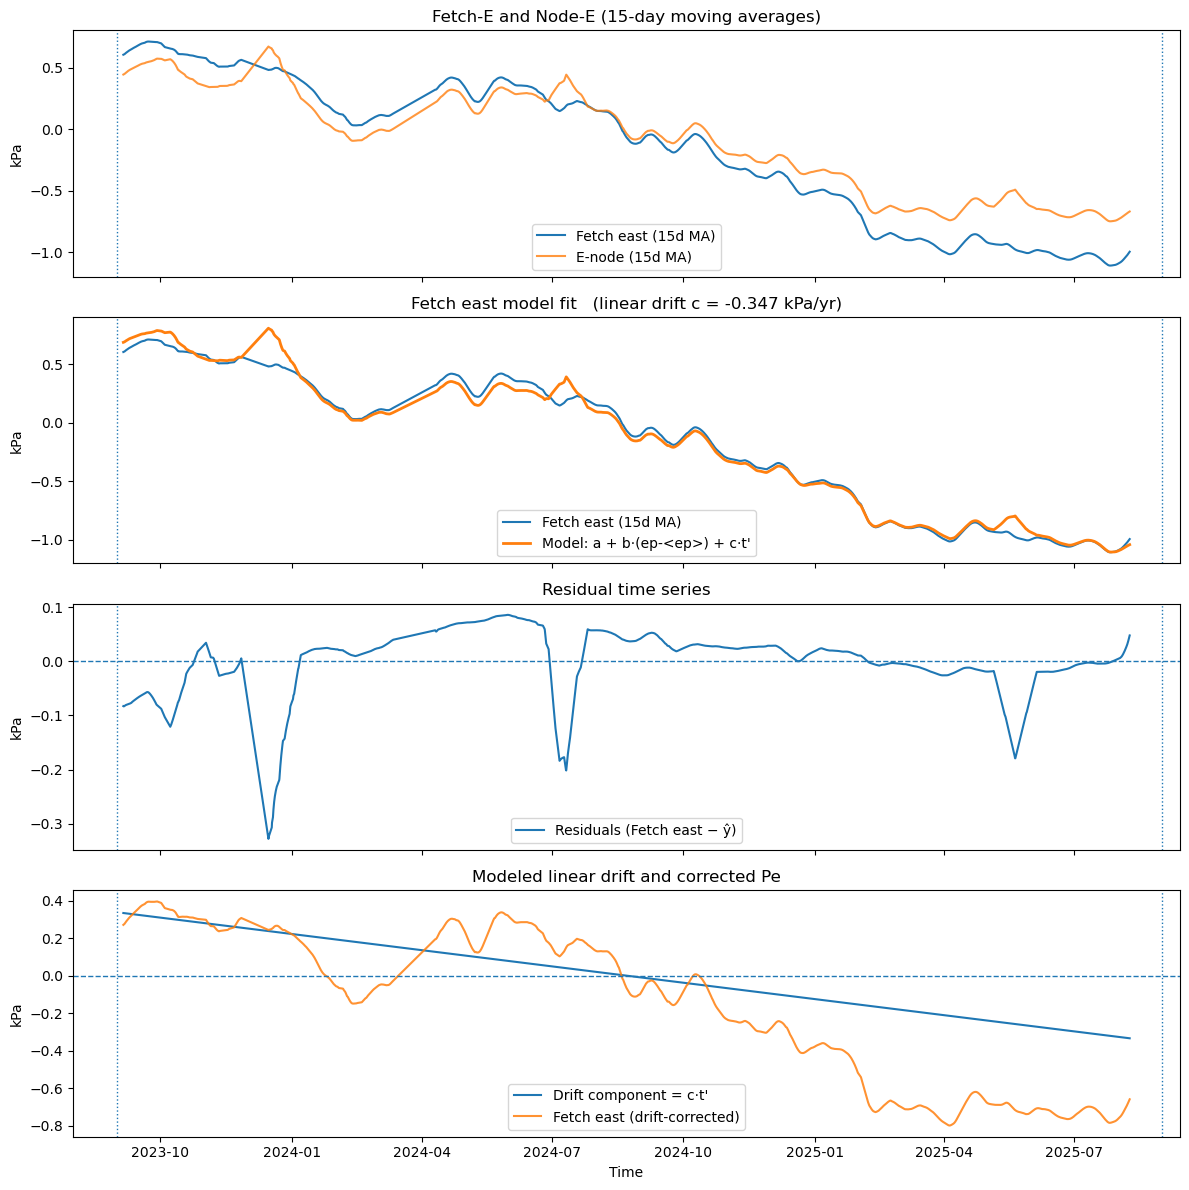

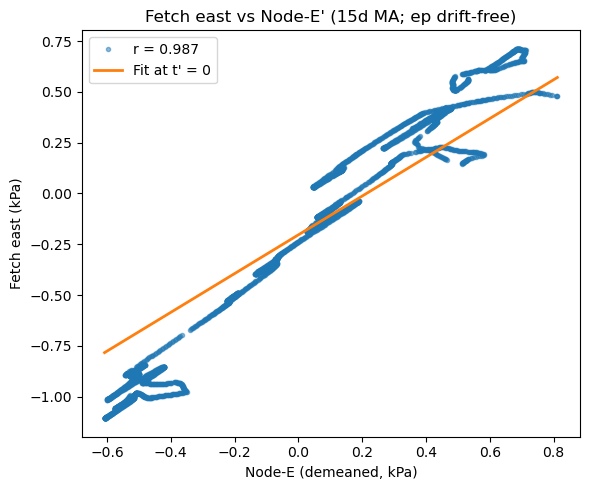

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------- 0) window + prep -----------
t0 = pd.Timestamp('2023-09-01')
t1 = pd.Timestamp('2025-09-01')

df = merged.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")
try:
    df["time"] = df["time"].dt.tz_convert(None)
except Exception:
    try:
        df["time"] = df["time"].dt.tz_localize(None)
    except Exception:
        pass

# IMPORTANT: keep rows with Pe (drifting) and ep (drift-free)
df = df.dropna(subset=["time", "Pe", "ep"]).sort_values("time")
df = df[(df["time"] >= t0) & (df["time"] < t1)].copy()
if df.empty:
    raise ValueError("Pe drift model window has no data after filtering.")

# 15-day moving averages (time-based) for stability
tmp = df.set_index("time").sort_index()
ma = tmp[["Pe", "ep"]].rolling("15D").mean()
ma = ma.dropna().copy()
ma["time"] = ma.index

# ----------- 1) regressors: ep' and centered time t' (years) -----------
# ep is drift-free -> use demeaned ep to capture coupling only
ep_mean = ma["ep"].mean()
ma["ep_dm"] = ma["ep"] - ep_mean

t_mid = ma.index[0] + (ma.index[-1] - ma.index[0]) / 2
ma["tprime_years"] = (ma.index - t_mid).total_seconds() / (365.25 * 86400.0)

# ----------- 2) fit Pe ~ 1 + (ep - <ep>) + c * t' -----------
y = ma["Pe"].to_numpy(float)
A = np.column_stack([
    np.ones(len(ma)),
    ma["ep_dm"].to_numpy(float),
    ma["tprime_years"].to_numpy(float)
])
coef, *_ = np.linalg.lstsq(A, y, rcond=None)
a_e, b_e, c_e = coef  # c_e is the linear drift rate in kPa/yr

ma["Pe_hat"] = A @ coef
ma["resid"]  = y - ma["Pe_hat"]
ma["drift_component"] = c_e * ma["tprime_years"]  # the piece we remove
# DRIFT-CORRECTED Pe: subtract ONLY the linear drift term
ma["Pe_driftcorr"] = ma["Pe"] - ma["drift_component"]

print("\nPe drift model over 2023-09 to 2025-09 (ep = drift-free reference)")
print(f"a_e (kPa)         = {a_e:.4f}")
print(f"b_e (kPa/kPa)     = {b_e:.4f}   # coupling to ep (drift-free)")
print(f"c_e (kPa/yr)      = {c_e:.4f}   # Pe linear drift rate")
print(f"RMSE (kPa)        = {np.sqrt(np.mean(ma['resid']**2)):.4f}")
print(f"N (15d-MA points) = {len(ma)}")

# ----------- 3) plots -----------
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# (a) Pe vs ep (both 15d MA)
axes[0].plot(ma["time"], ma["Pe"], label="Fetch east (15d MA)")
axes[0].plot(ma["time"], ma["ep"], label="E-node (15d MA)", alpha=0.8)
axes[0].set_ylabel("kPa"); axes[0].legend(loc="best")
axes[0].set_title("Fetch-E and Node-E (15-day moving averages)")

# (b) Pe vs model fit
axes[1].plot(ma["time"], ma["Pe"], label="Fetch east (15d MA)")
axes[1].plot(ma["time"], ma["Pe_hat"], label="Model: a + b·(ep-<ep>) + c·t'", linewidth=2)
axes[1].set_ylabel("kPa"); axes[1].legend(loc="best")
axes[1].set_title(f"Fetch east model fit   (linear drift c = {c_e:.3f} kPa/yr)")

# (c) residuals
axes[2].plot(ma["time"], ma["resid"], label="Residuals (Fetch east − ŷ)")
axes[2].axhline(0, ls="--", lw=1)
axes[2].set_ylabel("kPa"); axes[2].legend(loc="best")
axes[2].set_title("Residual time series")

# (d) drift term & drift-corrected Pe
axes[3].plot(ma["time"], ma["drift_component"], label="Drift component = c·t'")
axes[3].plot(ma["time"], ma["Pe_driftcorr"], label="Fetch east (drift-corrected)", alpha=0.85)
axes[3].axhline(0, ls="--", lw=1)
axes[3].set_ylabel("kPa"); axes[3].set_xlabel("Time"); axes[3].legend(loc="best")
axes[3].set_title("Modeled linear drift and corrected Pe")

for ax in axes:
    ax.axvline(t0, ls=":", lw=1)
    ax.axvline(t1, ls=":", lw=1)

plt.tight_layout(); plt.show()

# ----------- 4) cross-plot: ep' vs Pe (fit at t'=0) -----------
r = np.corrcoef(ma["ep_dm"], ma["Pe"])[0,1]
plt.figure(figsize=(6,5))
plt.plot(ma["ep_dm"], ma["Pe"], '.', alpha=0.5, label=f"r = {r:.3f}")
xg = np.linspace(ma["ep_dm"].min(), ma["ep_dm"].max(), 200)
yg = a_e + b_e * xg  # slice at t'=0
plt.plot(xg, yg, lw=2, label="Fit at t' = 0")
plt.xlabel("Node-E (demeaned, kPa)"); plt.ylabel("Fetch east (kPa)")
plt.title("Fetch east vs Node-E' (15d MA; ep drift-free)"); plt.legend(); plt.tight_layout(); plt.show()



Pw drift model over 2023-09 to 2025-09 (wp = Node-B drift-free reference)
a_w (kPa)         = -0.1400
b_w (kPa/kPa)     = 0.9615   # coupling to wp (drift-free)
c_w (kPa/yr)      = 0.3316   # Pw linear drift rate
RMSE (kPa)        = 0.0411
N (15d-MA points) = 3599


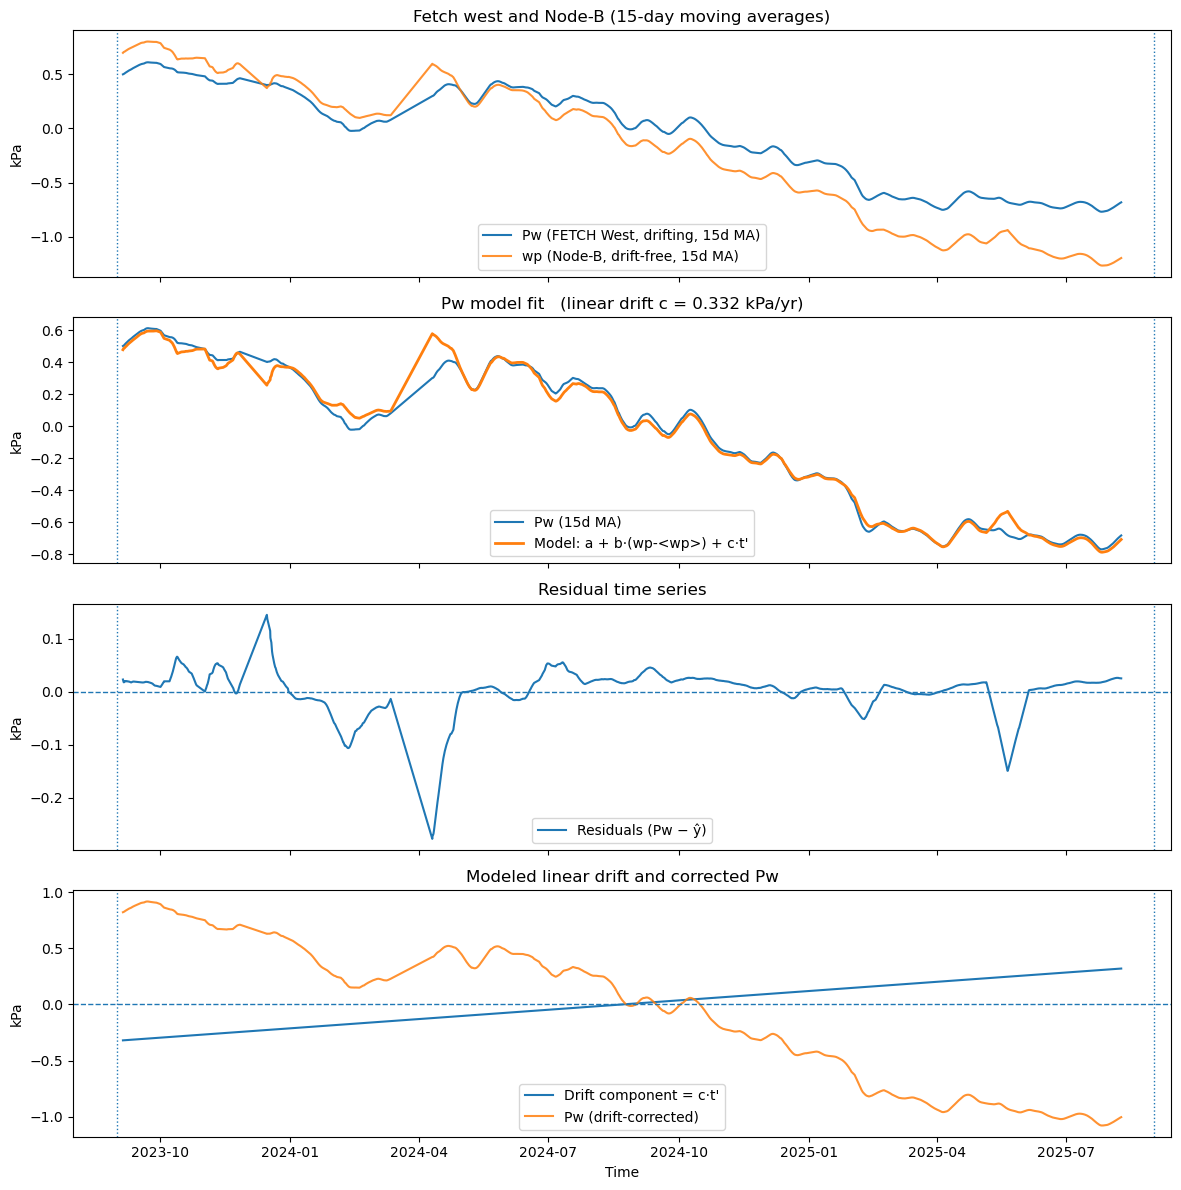

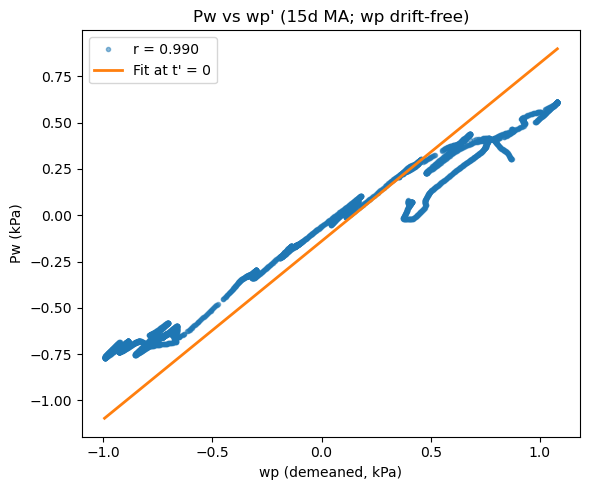

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------- 0) window + prep -----------
t0 = pd.Timestamp('2023-09-01')
t1 = pd.Timestamp('2025-09-01')

df = merged.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")
try:
    df["time"] = df["time"].dt.tz_convert(None)
except Exception:
    try:
        df["time"] = df["time"].dt.tz_localize(None)
    except Exception:
        pass

# Keep Pw (drifting, FETCH West) and wp (drift-free, Node-B)
df = df.dropna(subset=["time", "Pw", "wp"]).sort_values("time")
df = df[(df["time"] >= t0) & (df["time"] < t1)].copy()
if df.empty:
    raise ValueError("Pw drift model window has no data after filtering.")

# 15-day moving averages (time-based)
tmp = df.set_index("time").sort_index()
ma = tmp[["Pw", "wp"]].rolling("15D").mean()
ma = ma.dropna().copy()
ma["time"] = ma.index

# ----------- 1) regressors: wp' and centered time t' (years) -----------
wp_mean = ma["wp"].mean()
ma["wp_dm"] = ma["wp"] - wp_mean

t_mid = ma.index[0] + (ma.index[-1] - ma.index[0]) / 2
ma["tprime_years"] = (ma.index - t_mid).total_seconds() / (365.25 * 86400.0)

# ----------- 2) fit Pw ~ 1 + (wp - <wp>) + c * t' -----------
y = ma["Pw"].to_numpy(float)
A = np.column_stack([
    np.ones(len(ma)),
    ma["wp_dm"].to_numpy(float),
    ma["tprime_years"].to_numpy(float)
])
coef, *_ = np.linalg.lstsq(A, y, rcond=None)
a_w, b_w, c_w = coef  # c_w is the linear drift rate in kPa/yr

ma["Pw_hat"] = A @ coef
ma["resid"]  = y - ma["Pw_hat"]
ma["drift_component"] = c_w * ma["tprime_years"]        # the piece we remove
ma["Pw_driftcorr"]    = ma["Pw"] - ma["drift_component"] # DRIFT-corrected Pw

print("\nPw drift model over 2023-09 to 2025-09 (wp = Node-B drift-free reference)")
print(f"a_w (kPa)         = {a_w:.4f}")
print(f"b_w (kPa/kPa)     = {b_w:.4f}   # coupling to wp (drift-free)")
print(f"c_w (kPa/yr)      = {c_w:.4f}   # Pw linear drift rate")
print(f"RMSE (kPa)        = {np.sqrt(np.mean(ma['resid']**2)):.4f}")
print(f"N (15d-MA points) = {len(ma)}")

# ----------- 3) plots -----------
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# (a) Pw vs wp (both 15d MA)
axes[0].plot(ma["time"], ma["Pw"], label="Pw (FETCH West, drifting, 15d MA)")
axes[0].plot(ma["time"], ma["wp"], label="wp (Node-B, drift-free, 15d MA)", alpha=0.85)
axes[0].set_ylabel("kPa"); axes[0].legend(loc="best")
axes[0].set_title("Fetch west and Node-B (15-day moving averages)")

# (b) Pw vs model fit
axes[1].plot(ma["time"], ma["Pw"], label="Pw (15d MA)")
axes[1].plot(ma["time"], ma["Pw_hat"], label="Model: a + b·(wp-<wp>) + c·t'", linewidth=2)
axes[1].set_ylabel("kPa"); axes[1].legend(loc="best")
axes[1].set_title(f"Pw model fit   (linear drift c = {c_w:.3f} kPa/yr)")

# (c) residuals
axes[2].plot(ma["time"], ma["resid"], label="Residuals (Pw − ŷ)")
axes[2].axhline(0, ls="--", lw=1)
axes[2].set_ylabel("kPa"); axes[2].legend(loc="best")
axes[2].set_title("Residual time series")

# (d) drift term & drift-corrected Pw
axes[3].plot(ma["time"], ma["drift_component"], label="Drift component = c·t'")
axes[3].plot(ma["time"], ma["Pw_driftcorr"], label="Pw (drift-corrected)", alpha=0.85)
axes[3].axhline(0, ls="--", lw=1)
axes[3].set_ylabel("kPa"); axes[3].set_xlabel("Time"); axes[3].legend(loc="best")
axes[3].set_title("Modeled linear drift and corrected Pw")

for ax in axes:
    ax.axvline(t0, ls=":", lw=1)
    ax.axvline(t1, ls=":", lw=1)

plt.tight_layout(); plt.show()

# ----------- 4) cross-plot: wp' vs Pw (fit at t'=0) -----------
r = np.corrcoef(ma["wp_dm"], ma["Pw"])[0,1]
plt.figure(figsize=(6,5))
plt.plot(ma["wp_dm"], ma["Pw"], '.', alpha=0.5, label=f"r = {r:.3f}")
xg = np.linspace(ma["wp_dm"].min(), ma["wp_dm"].max(), 200)
yg = a_w + b_w * xg  # slice at t'=0
plt.plot(xg, yg, lw=2, label="Fit at t' = 0")
plt.xlabel("wp (demeaned, kPa)"); plt.ylabel("Pw (kPa)")
plt.title("Pw vs wp' (15d MA; wp drift-free)"); plt.legend(); plt.tight_layout(); plt.show()
